# 📊 Task-1: Applied EDA for Complaints Dataset

### 🎯 Objective
The goal of this notebook is to perform Applied Exploratory Data Analysis (EDA) on the complaints dataset to:
- Understand dataset structure and quality
- Identify missing values and duplicates
- Analyze distribution of key columns
- Focus on NLP relevance (complaint narratives)
- Map product categories into required target groups
- Prepare a cleaned, filtered dataset for the next task

---

### 🗂 Target Product Categories
The project focuses on the following products:

| Target Product | Dataset Labels Considered |
|---------------|----------------------------|
| Personal Loan | Payday loan / Student loan / Consumer loan... |
| Money Transfers | Money service / Money Transfer |
| Savings Account | Checking or Savings account |
| Credit Card | Credit card / Prepaid card |

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 300)

data_path = "../data/raw/complaints.csv"
df = pd.read_csv(data_path)

df.shape


C:\Users\derej\AppData\Local\Temp\ipykernel_8684\1954556414.py:9: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


(9609797, 18)

In [ ]:
df.head()

## ℹ️ Dataset Information
Check datatypes, non-null records, and basic structure.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.3+

## ❓ Missing Values per Column
Understanding missing data is critical for NLP and ML tasks.


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean()*100).sort_values(ascending=False)

missing_df = pd.concat([missing, missing_percent], axis=1)
missing_df.columns = ["Missing Count", "Missing %"]
missing_df


,Missing Count,Missing %
Tags,8981029,93.457011
Consumer disputed?,8841498,92.005044
Consumer complaint narrative,6629041,68.982113
Company public response,4770207,49.638999
Consumer consent provided?,1649561,17.165409
Sub-issue,839522,8.736105
Sub-product,235295,2.448491
State,54516,0.567296
ZIP code,30228,0.314554
Company response to consumer,20,0.000208


## 🔍 Duplicate Records
Check if dataset contains duplicate complaints.


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 🏷 Product Distribution (Original)
This helps us understand which product categories dominate.


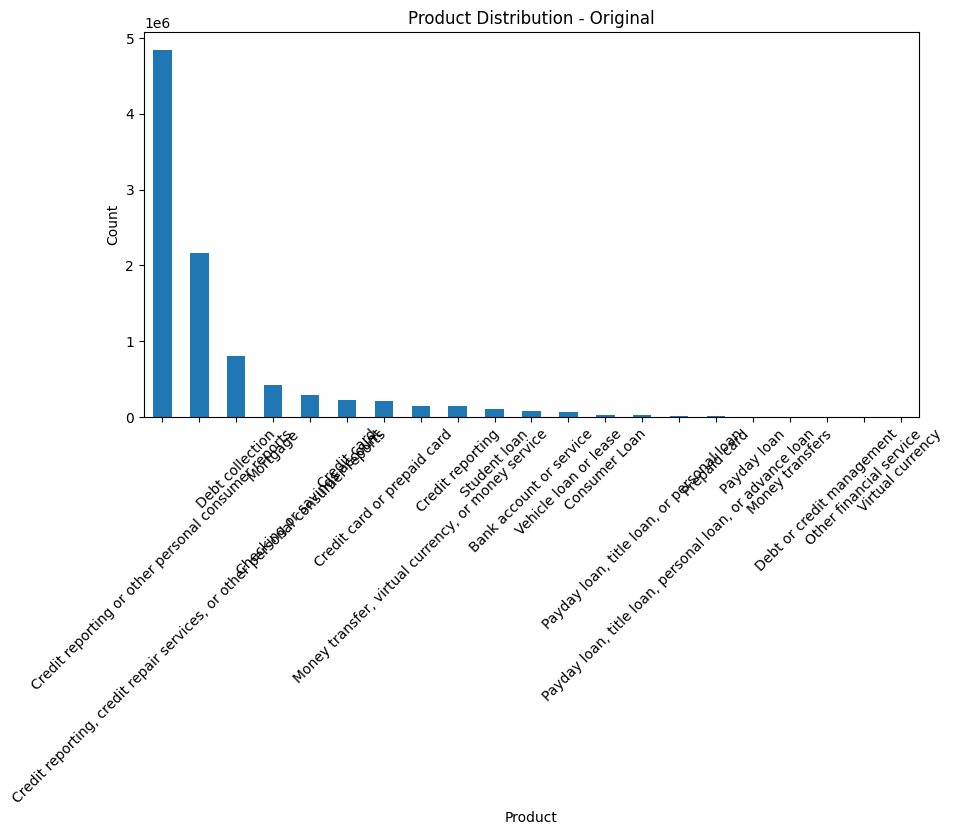

In [5]:
plt.figure(figsize=(10,5))
df["Product"].value_counts().plot(kind="bar")
plt.title("Product Distribution - Original")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


## 🎯 Target Product Mapping
We map multiple related labels into required 4 main categories.

In [6]:
mapping_rules = {
    "Personal loan": [
        "Payday loan, title loan, personal loan, or advance loan",
        "Student loan",
        "Payday loan, title loan, or personal loan",
        "Consumer Loan"
    ],
    
    "Money transfers":[
        "Money transfer, virtual currency, or money service",
        "Money transfers"
    ],
    
    "Savings account":[
        "Checking or savings account"
    ],
    
    "Credit card":[
        "Credit card or prepaid card",
        "Credit card"
    ]
}

def map_product(value):
    for key, values in mapping_rules.items():
        if value in values:
            return key
    return None

df["Product_Cleaned"] = df["Product"].apply(map_product)

df["Product_Cleaned"].value_counts(dropna=False)


Product_Cleaned
None               8546698
Credit card         433055
Savings account     291178
Personal loan       188446
Money transfers     150420
Name: count, dtype: int64

## 🧹 Filter Dataset to Only Target Categories


In [7]:
df_filtered = df[df["Product_Cleaned"].notna()].copy()
df_filtered.shape


(1063099, 19)

## 📦 Product Distribution After Filtering


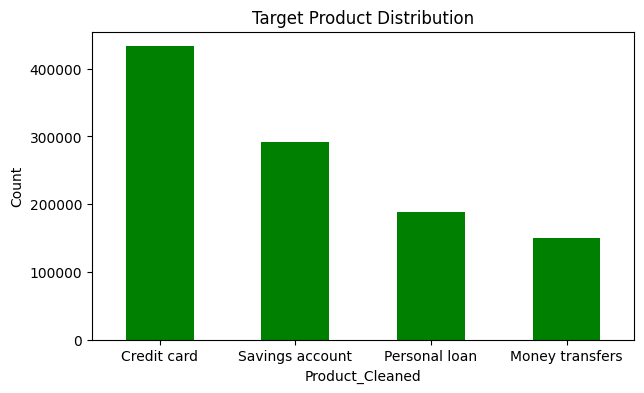

In [8]:
plt.figure(figsize=(7,4))
df_filtered["Product_Cleaned"].value_counts().plot(kind="bar", color="green")
plt.title("Target Product Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [ ]:
# NLP Perspective — Narrative Availability
# We must check if we actually have text to train on.
df_filtered["Consumer complaint narrative"].isna().mean()*100


np.float64(51.35523596579434)

## ✂️ Text Length Analysis
Check very short / long complaints to understand data quality.


In [10]:
df_filtered["text_length"] = df_filtered["Consumer complaint narrative"].astype(str).str.len()

df_filtered["text_length"].describe()


count    1.063099e+06
mean     5.624568e+02
std      1.053426e+03
min      3.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      7.390000e+02
max      3.295900e+04
Name: text_length, dtype: float64

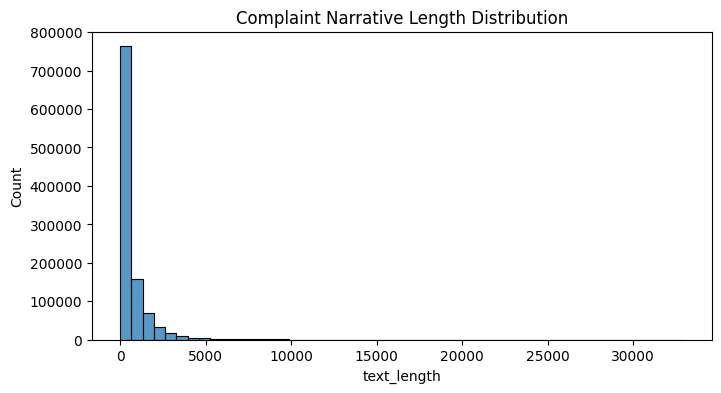

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df_filtered["text_length"], bins=50)
plt.title("Complaint Narrative Length Distribution")
plt.show()

## 🚨 Extremely Short or Long Complaints


In [12]:
short_texts = df_filtered[df_filtered["text_length"] < 50]
long_texts = df_filtered[df_filtered["text_length"] > 3000]

print("Very Short Complaints:", short_texts.shape[0])
print("Very Long Complaints:", long_texts.shape[0])


Very Short Complaints: 547665
Very Long Complaints: 31512


In [13]:
missing_narratives = df_filtered[df_filtered["Consumer complaint narrative"].isna()]
missing_narratives.shape


(545957, 20)

In [14]:
df_filtered["State"].value_counts().head(10)


State
CA    138098
FL     90785
TX     90622
NY     81411
GA     48047
IL     47501
PA     41530
NJ     37880
OH     31891
VA     31480
Name: count, dtype: int64

In [15]:
df_filtered["Company"].value_counts().head(10)


Company
JPMORGAN CHASE & CO.                     83816
BANK OF AMERICA, NATIONAL ASSOCIATION    74843
CITIBANK, N.A.                           73153
CAPITAL ONE FINANCIAL CORPORATION        71245
WELLS FARGO & COMPANY                    62878
Block, Inc.                              50704
SYNCHRONY FINANCIAL                      37591
Navient Solutions, LLC.                  35264
AMERICAN EXPRESS COMPANY                 29645
Paypal Holdings, Inc                     25171
Name: count, dtype: int64